# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [2]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [3]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Đoàn Văn Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600046"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [4]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://tears-afternoon-girls-lenders.trycloudflare.com"  # <-- Okedone

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [5]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 1.3% | Mem: 0.6/16.0GB | Power: 36W | Temp: 37°C
   GPU 1 [T4] 🟢 Util: 13.6% | Mem: 1.2/16.0GB | Power: 39W | Temp: 42°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 2.1% | Mem: 1.4/80.0GB | Power: 49W | Temp: 40°C
   GPU 1 [A100] 🟢 Util: 5.1% | Mem: 1.5/80.0GB | Power: 43W | Temp: 43°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 2.7% | Mem: 1.1/32.0GB | Power: 48W | Temp: 35°C
   GPU 1 [V100] 🟢 Util: 6.9% | Mem: 1.0/32.0GB | Power: 34W | Temp: 30°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 3.6% | Mem: 1.5/16.0GB | Power: 34W | Temp: 34°C
   GPU 1 [T4] 🟢 Util: 11.9% | Mem: 1.2/16.0GB | Power: 22W | Temp: 40°C


In [6]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     5.9%
Memory Used:         9.4 GB
Memory Capacity:     288.0 GB
Total Power Draw:    306 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [7]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 54.1%


In [8]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [9]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2734     21.9    % medium
A100       $3.67       $2.1281     42.0    % high
V100       $2.48       $1.7443     29.7    % high


In [10]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [11]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 1
   Still active: 2

   ⚠️  Preempted:
      - spot-t4-001 (ran for 4s, 30s warning)

💰 Spot Savings Report:
   Spot cost:        $0.0012
   On-demand equiv:  $0.0039
   Total saved:      $0.0027 (70.0%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [12]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [13]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 54.1% within thresholds [25.0-70.0%]
   Current utilization: 54.1%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 54.1% | Nodes: 4→4
   Cycle 2: no_action    | Util: 54.1% | Nodes: 4→4
   Cycle 3: no_action    | Util: 54.1% | Nodes: 4→4
   Cycle 4: no_action    | Util: 54.1% | Nodes: 4→4
   Cycle 5: no_action    | Util: 54.1% | Nodes: 4→4


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [14]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [15]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [16]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [17]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 54.1% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.0929 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

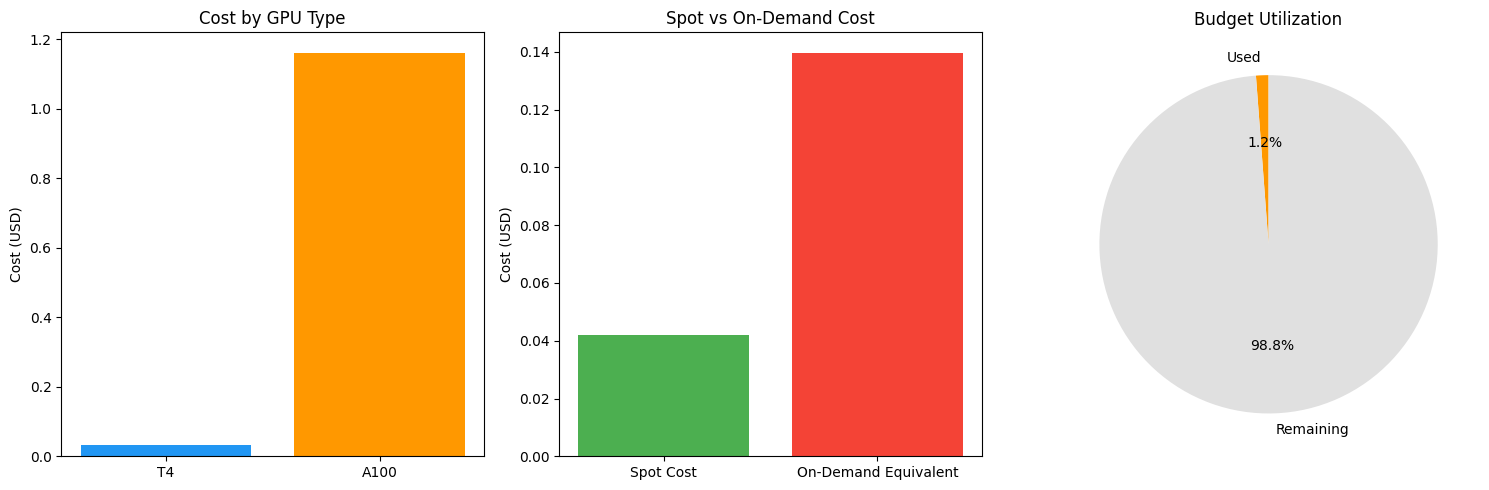

📊 Chart saved as finops_cost_breakdown.png


In [18]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

📈 Collecting time-series data (10 snapshots)...


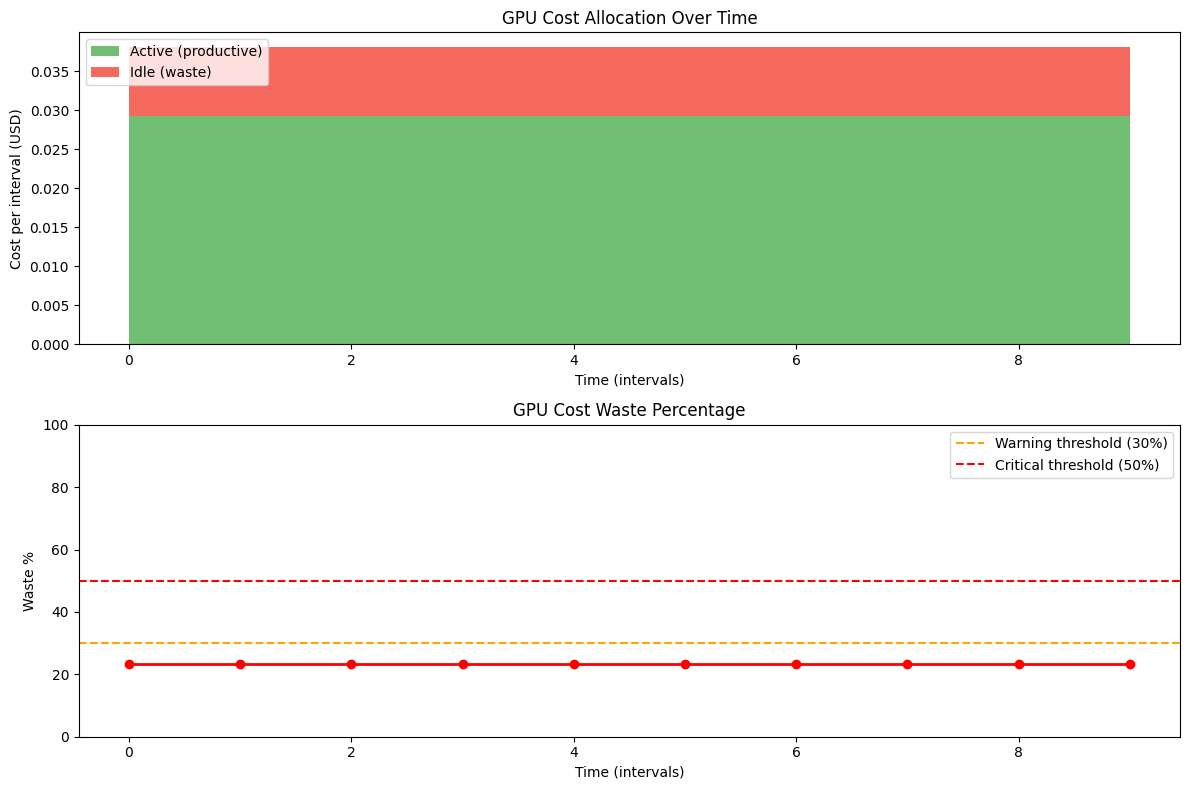

In [19]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [20]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 54.1% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 77.3% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 77.3% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.1353 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [21]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [22]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.2W
   Temp: 39C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.238
   temp_c: 39.0

   Method: pynvml

Ready for training.


In [23]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:13<00:00, 13.0MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [24]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 1/3 | Loss: 2.0106 | Acc: 28.1% | Time: 39.5s | Samples: 40
   Epoch 2/3 | Loss: 1.4567 | Acc: 46.5% | Time: 40.1s | Samples: 40
   Epoch 3/3 | Loss: 1.1763 | Acc: 57.5% | Time: 43.8s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      123.4s
   Peak memory:     0.82 GB
   Avg GPU util:    96.0%
   Avg power:       66.3W
   Avg temperature: 66.2C
   Max GPU util:    99.0%
   Estimated cost:  $0.011996


In [25]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 2.0784 | Acc: 25.5% | Time: 19.7s | Samples: 40
   Epoch 2/3 | Loss: 1.4057 | Acc: 48.4% | Time: 20.6s | Samples: 40
   Epoch 3/3 | Loss: 1.0975 | Acc: 60.7% | Time: 19.4s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      59.8s
   Peak memory:     0.60 GB
   Avg GPU util:    92.5%
   Avg power:       64.7W
   Avg temperature: 78.2C
   Max GPU util:    95.0%
   Estimated cost:  $0.005818


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                123.4           59.8            2.06x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.011996       $0.005818       $0.006178 saved
Cost Saving %             ---             ---             51.5%
Avg GPU Util %            96.0            92.5           
Avg Power (W)             66.3            64.7           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.07 -> SAVE $4.33
   1 week training: FP32=$58.80 vs AMP=$28.52 -> SAVE $30.28
   1 month training: FP32=$252.00 vs AMP=$122.23 -> SAVE $129.77


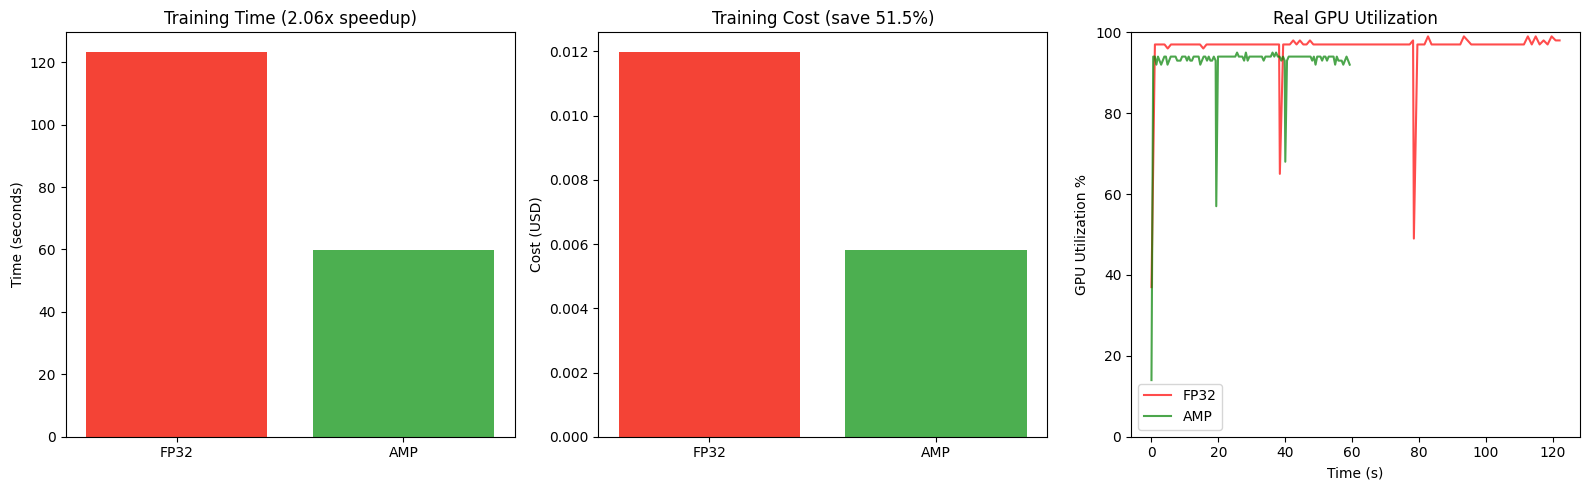

In [26]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.012000 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.004100

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.013700
   Total Savings:   $0.004100
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


Real GPU Telemetry During Training


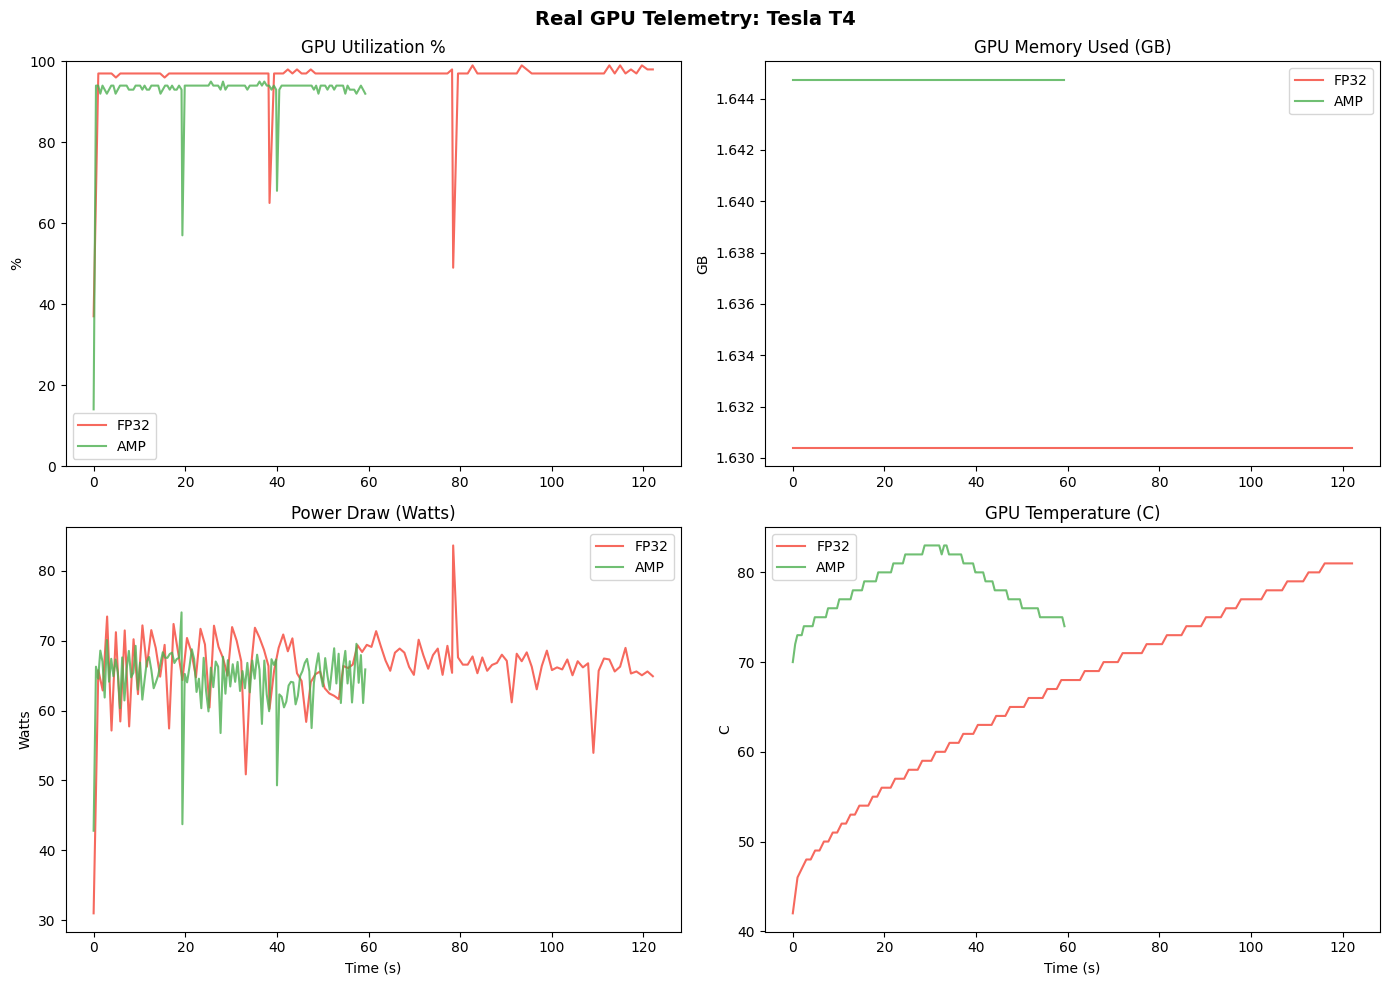

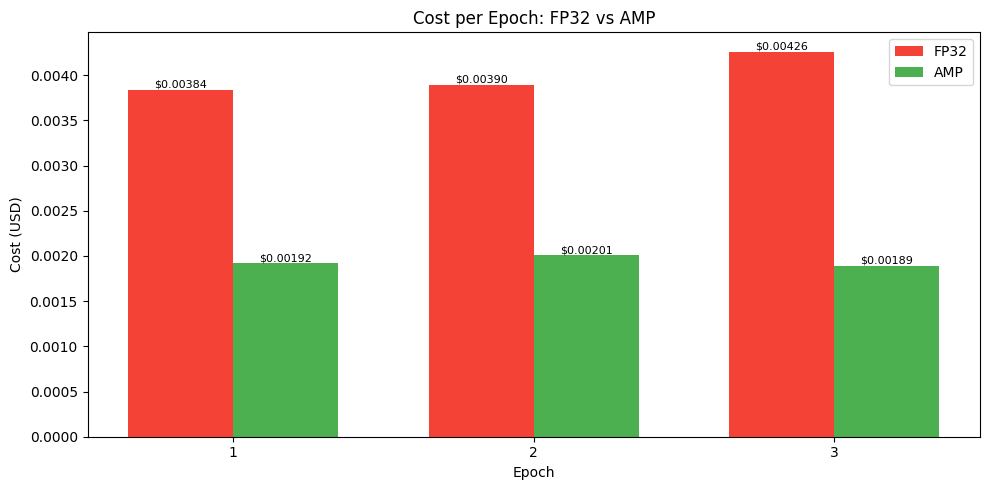


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [28]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

EXERCISE 8.5.1: Multi-GPU Cost Analysis

📊 Multi-GPU Cost Analysis: A100 ($3.67/hr)
   Base training time: 2.0h for 1 GPU

GPUs     Speedup    Efficiency   Time (h)     Total Cost   Cost Ratio  
------------------------------------------------------------------
1        1.00       100.0      % 2.00         $7.34      1.00        x
2        1.80       90.0       % 1.11         $8.16      1.11        x
4        3.20       80.0       % 0.62         $9.18      1.25        x
8        5.00       62.5       % 0.40         $11.74     1.60        x

🏆 Best efficiency (cost ratio): 1 GPUs
🏆 Best value (cost/speedup):    8 GPUs


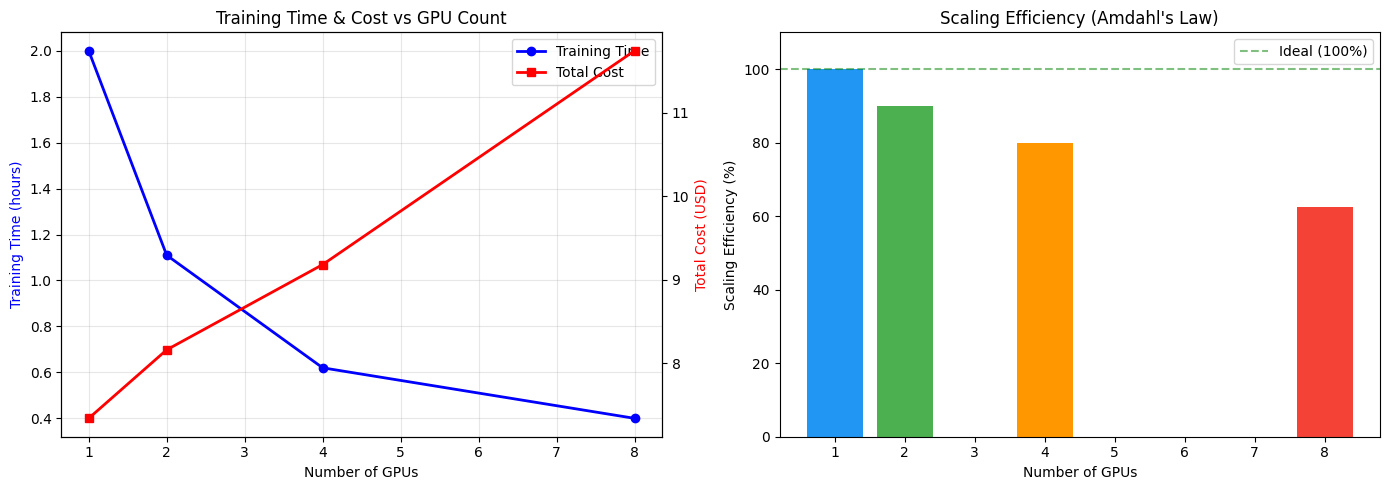

📊 Chart saved as multi_gpu_scaling.png


In [29]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze multi-GPU training costs considering sub-linear scaling efficiency.
    
    Parameters:
        base_time_hours (float): Single-GPU training time in hours
        gpu_type (str): GPU type (T4, A100, etc.)
        gpu_counts (list): List of GPU counts to analyze (e.g., [1, 2, 4, 8])
        scaling_factors (dict, optional): Scaling efficiency factors {gpu_count: efficiency}
                                         If None, assume realistic sub-linear scaling
    
    Returns:
        dict: Analysis with costs, times, and efficiency metrics
    """
    price = GPU_PRICING.get(gpu_type, 0.35)
    
    # Realistic sub-linear scaling factors (Amdahl's law simulation)
    if scaling_factors is None:
        scaling_factors = {
            1: 1.0,
            2: 1.8,   # 90% efficiency
            4: 3.2,   # 80% efficiency
            8: 5.0,   # 62.5% efficiency
            16: 7.5,  # 47% efficiency
        }
    
    results = []
    for n_gpu in gpu_counts:
        efficiency = scaling_factors.get(n_gpu, min(n_gpu ** 0.7, n_gpu * 0.7))
        speedup = efficiency
        time_hours = base_time_hours / speedup if speedup > 0 else float('inf')
        total_cost = time_hours * price * n_gpu
        base_cost = base_time_hours * price
        cost_ratio = total_cost / base_cost if base_cost > 0 else float('inf')
        
        results.append({
            'gpu_count': n_gpu,
            'speedup': round(speedup, 2),
            'efficiency_pct': round((speedup / n_gpu) * 100, 1),
            'time_hours': round(time_hours, 2),
            'total_cost': round(total_cost, 2),
            'cost_ratio': round(cost_ratio, 2),
            'cost_per_gpu_hour': round(total_cost / (time_hours * n_gpu), 4) if time_hours > 0 else 0,
        })
    
    # Find optimal GPU count (lowest total cost or best cost-performance)
    best_efficiency = min(results, key=lambda r: r['cost_ratio'])
    best_value = min(results, key=lambda r: r['total_cost'] / max(r['speedup'], 0.01))
    
    return {
        'gpu_type': gpu_type,
        'price_per_hour': price,
        'base_time_hours': base_time_hours,
        'configurations': results,
        'best_efficiency': best_efficiency,
        'best_value': best_value,
    }

# Test data
base_training_time = 2.0  # hours for single GPU on A100
test_gpu_counts = [1, 2, 4, 8]
test_gpu_type = "A100"

# Run analysis
analysis = analyze_multi_gpu_cost(base_training_time, test_gpu_type, test_gpu_counts)

print(f"\n📊 Multi-GPU Cost Analysis: {test_gpu_type} (${analysis['price_per_hour']:.2f}/hr)")
print(f"   Base training time: {base_training_time}h for 1 GPU")
print()
print(f"{'GPUs':<8} {'Speedup':<10} {'Efficiency':<12} {'Time (h)':<12} {'Total Cost':<12} {'Cost Ratio':<12}")
print("-" * 66)
for r in analysis['configurations']:
    print(f"{r['gpu_count']:<8} {r['speedup']:<10.2f} {r['efficiency_pct']:<11.1f}% {r['time_hours']:<12.2f} ${r['total_cost']:<9.2f} {r['cost_ratio']:<12.2f}x")

print(f"\n🏆 Best efficiency (cost ratio): {analysis['best_efficiency']['gpu_count']} GPUs")
print(f"🏆 Best value (cost/speedup):    {analysis['best_value']['gpu_count']} GPUs")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

gpu_counts = [r['gpu_count'] for r in analysis['configurations']]
times = [r['time_hours'] for r in analysis['configurations']]
costs = [r['total_cost'] for r in analysis['configurations']]
efficiencies = [r['efficiency_pct'] for r in analysis['configurations']]

ax1.plot(gpu_counts, times, 'b-o', linewidth=2, label='Training Time')
ax1_twin = ax1.twinx()
ax1_twin.plot(gpu_counts, costs, 'r-s', linewidth=2, label='Total Cost')
ax1.set_xlabel('Number of GPUs')
ax1.set_ylabel('Training Time (hours)', color='b')
ax1_twin.set_ylabel('Total Cost (USD)', color='r')
ax1.set_title('Training Time & Cost vs GPU Count')
ax1.grid(True, alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax2.bar(gpu_counts, efficiencies, color=['#2196F3', '#4CAF50', '#FF9800', '#F44336'])
ax2.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Ideal (100%)')
ax2.set_xlabel('Number of GPUs')
ax2.set_ylabel('Scaling Efficiency (%)')
ax2.set_title('Scaling Efficiency (Amdahl\'s Law)')
ax2.legend()
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('multi_gpu_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as multi_gpu_scaling.png")

EXERCISE 8.5.2: Project Cost Forecasting

📈 PROJECT COST FORECAST

Phase                     GPU      Hours    Base Cost    CI Lower     CI Upper    
-----------------------------------------------------------------------------
Data Preparation          T4       40       $14.00     $9.88      $18.12    
Model Training            A100     120      $1761.60   $898.42    $2624.78  
Hyperparameter Tuning     A100     60       $1761.60   $725.78    $2797.42  
Model Evaluation          T4       20       $14.00     $11.26     $16.74    
-----------------------------------------------------------------------------
TOTAL (Base):                               $3551.20  
Contingency                                 20% = $710.24   
TOTAL (with cont.)                          $4261.44  

📊 Confidence Interval (95%):
   Best case:   $2202.85
   Expected:    $3551.20
   Worst case:  $5609.79


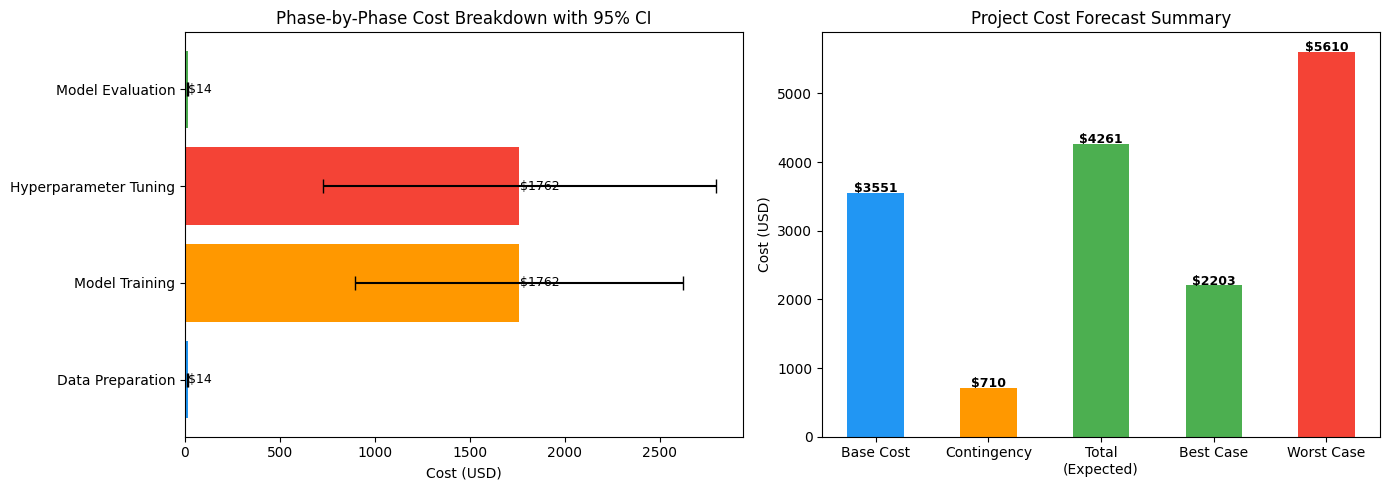

📊 Chart saved as project_forecast.png


In [30]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast multi-phase project costs with confidence intervals.
    
    Parameters:
        phases (list): List of phase dictionaries, each with:
                      - name: str
                      - gpu_type: str
                      - gpu_count: int
                      - duration_hours: float
                      - uncertainty_pct: float (e.g., 0.2 for 20% uncertainty)
        contingency_pct (float): Percentage buffer for unexpected costs (default 20%)
        confidence_level (float): Confidence level for intervals (0.95 = 95%)
    
    Returns:
        dict: Forecast with base cost, contingency, confidence intervals
    """
    z_score = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}.get(confidence_level, 1.96)
    
    phase_details = []
    total_base_cost = 0
    total_variance = 0
    
    for phase in phases:
        price = GPU_PRICING.get(phase['gpu_type'], 0.35)
        base_cost = phase['duration_hours'] * price * phase['gpu_count']
        
        # Uncertainty range
        std_dev = base_cost * phase['uncertainty_pct']
        ci_lower = base_cost - z_score * std_dev
        ci_upper = base_cost + z_score * std_dev
        
        phase_details.append({
            'name': phase['name'],
            'gpu_type': phase['gpu_type'],
            'gpu_count': phase['gpu_count'],
            'duration_hours': phase['duration_hours'],
            'base_cost': round(base_cost, 2),
            'uncertainty_pct': phase['uncertainty_pct'] * 100,
            'ci_lower': round(max(ci_lower, 0), 2),
            'ci_upper': round(ci_upper, 2),
            'std_dev': round(std_dev, 2),
        })
        
        total_base_cost += base_cost
        total_variance += std_dev ** 2
    
    total_std = total_variance ** 0.5
    contingency = total_base_cost * (contingency_pct / 100)
    total_with_contingency = total_base_cost + contingency
    
    ci_lower_total = total_base_cost - z_score * total_std
    ci_upper_total = total_base_cost + z_score * total_std
    
    return {
        'phases': phase_details,
        'total_base_cost': round(total_base_cost, 2),
        'contingency_pct': contingency_pct,
        'contingency_amount': round(contingency, 2),
        'total_with_contingency': round(total_with_contingency, 2),
        'confidence_level': confidence_level,
        'ci_lower': round(max(ci_lower_total, 0), 2),
        'ci_upper': round(ci_upper_total, 2),
        'total_std': round(total_std, 2),
        'best_case': round(max(total_base_cost - z_score * total_std, 0), 2),
        'worst_case': round(total_base_cost + z_score * total_std + contingency, 2),
    }

# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

# Run forecast
forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)

print(f"\n📈 PROJECT COST FORECAST")
print("=" * 60)
print(f"\n{'Phase':<25} {'GPU':<8} {'Hours':<8} {'Base Cost':<12} {'CI Lower':<12} {'CI Upper':<12}")
print("-" * 77)
for p in forecast['phases']:
    print(f"{p['name']:<25} {p['gpu_type']:<8} {p['duration_hours']:<8.0f} ${p['base_cost']:<9.2f} ${p['ci_lower']:<9.2f} ${p['ci_upper']:<9.2f}")

print("-" * 77)
print(f"{'TOTAL (Base):':<25} {'':<8} {'':<8} ${forecast['total_base_cost']:<9.2f}")
print(f"{'Contingency':<25} {'':<8} {'':<8} {forecast['contingency_pct']:.0f}% = ${forecast['contingency_amount']:<9.2f}")
print(f"{'TOTAL (with cont.)':<25} {'':<8} {'':<8} ${forecast['total_with_contingency']:<9.2f}")
print(f"\n📊 Confidence Interval ({forecast['confidence_level']*100:.0f}%):")
print(f"   Best case:   ${forecast['best_case']:.2f}")
print(f"   Expected:    ${forecast['total_base_cost']:.2f}")
print(f"   Worst case:  ${forecast['worst_case']:.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Phase breakdown
phases_names = [p['name'] for p in forecast['phases']]
base_costs = [p['base_cost'] for p in forecast['phases']]
ci_lowers = [p['base_cost'] - p['ci_lower'] for p in forecast['phases']]
ci_uppers = [p['ci_upper'] - p['base_cost'] for p in forecast['phases']]

colors = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
bars = ax1.barh(phases_names, base_costs, color=colors, xerr=[ci_lowers, ci_uppers], 
                capsize=5, error_kw={'linewidth': 1.5})
ax1.set_xlabel('Cost (USD)')
ax1.set_title('Phase-by-Phase Cost Breakdown with 95% CI')
for bar, cost in zip(bars, base_costs):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'${cost:.0f}',
             va='center', fontsize=9)

# Forecast waterfall
categories = ['Base Cost', 'Contingency', 'Total\n(Expected)', 'Best Case', 'Worst Case']
values = [forecast['total_base_cost'], forecast['contingency_amount'], 
          forecast['total_with_contingency'], forecast['best_case'], forecast['worst_case']]
colors2 = ['#2196F3', '#FF9800', '#4CAF50', '#4CAF50', '#F44336']
bars2 = ax2.bar(categories, values, color=colors2, width=0.5)
ax2.set_ylabel('Cost (USD)')
ax2.set_title('Project Cost Forecast Summary')
for bar, val in zip(bars2, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'${val:.0f}',
             ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('project_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as project_forecast.png")

EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

💡 OPTIMIZATION OPPORTUNITY ANALYSIS

Current config: 4x A100 for 100h
Base cost: $1468.00
Realistic total savings: 74.5% ($1093.66)
Optimized cost: $374.34

Order  Strategy                            Savings    Amount       Effort   Risk     Priority  
-----------------------------------------------------------------------------------------
1      Switch to Mixed Precision (AMP)     25.0     % $367.00    LOW      LOW      25.00     
2      Optimize Batch Size                 15.0     % $220.20    LOW      LOW      15.00     
3      Use Spot Instances                  60.0     % $880.80    MEDIUM   HIGH     10.00     
4      Implement Early Stopping            20.0     % $293.60    MEDIUM   LOW      10.00     
5      Switch to More Efficient GPU Type   40.0     % $587.20    HIGH     MEDIUM   6.67      

📋 Implementation Roadmap:
   Step 1: Switch to Mixed Precision (AMP) → save $367.00 (cumulative: $367.00)
   Step 2: Optimize 

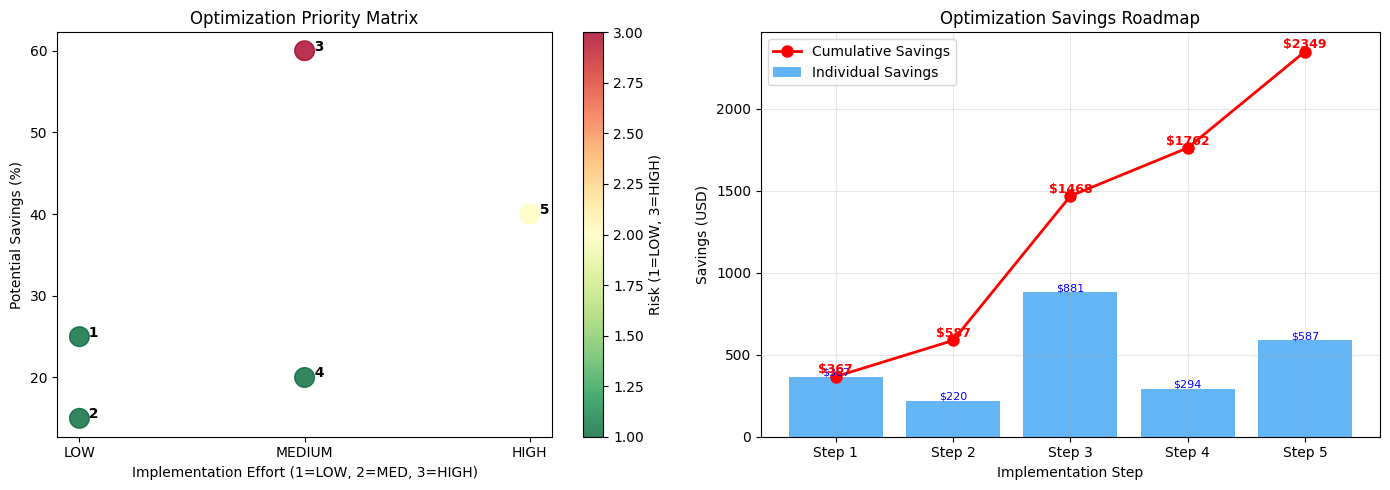

📊 Chart saved as optimization_roadmap.png


In [31]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize optimization strategies based on savings, effort, and risk.
    
    Parameters:
        current_config (dict): Current training configuration
        optimization_strategies (list): List of strategy dictionaries, each with:
                                      - name, savings_pct, implementation_effort, risk_level, dependencies
    
    Returns:
        dict: Prioritized recommendations with cumulative savings
    """
    effort_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    risk_score = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
    
    price = GPU_PRICING.get(current_config['gpu_type'], 0.35)
    base_cost = current_config['duration_hours'] * price * current_config['gpu_count']
    
    # Score and prioritize strategies
    scored = []
    for s in optimization_strategies:
        savings_amount = base_cost * s['savings_pct']
        effort = effort_score.get(s['implementation_effort'], 2)
        risk = risk_score.get(s['risk_level'], 2)
        
        # Priority score: higher savings, lower effort, lower risk = better
        priority_score = (s['savings_pct'] * 100) / (effort * risk)
        
        scored.append({
            **s,
            'savings_amount': round(savings_amount, 2),
            'effort_score': effort,
            'risk_score': risk,
            'priority_score': round(priority_score, 2),
        })
    
    # Sort by priority score (descending)
    scored.sort(key=lambda x: x['priority_score'], reverse=True)
    
    # Assign implementation order and calculate cumulative savings
    cumulative = 0
    for i, s in enumerate(scored):
        s['implementation_order'] = i + 1
        cumulative += s['savings_amount']
        s['cumulative_savings'] = round(cumulative, 2)
    
    roadmap = []
    for s in scored:
        roadmap.append({
            'step': s['implementation_order'],
            'action': s['name'],
            'savings_pct': s['savings_pct'] * 100,
            'savings_amount': s['savings_amount'],
            'cumulative_savings': s['cumulative_savings'],
            'effort': s['implementation_effort'],
            'risk': s['risk_level'],
        })
    
    total_savings_pct = sum(s['savings_pct'] for s in scored)
    # Adjust for overlapping savings (optimizations aren't purely additive)
    realistic_savings_pct = 1 - (1 - scored[0]['savings_pct']) * (1 - scored[1]['savings_pct']) * (1 - scored[2]['savings_pct']) if len(scored) >= 3 else total_savings_pct
    
    return {
        'base_cost': round(base_cost, 2),
        'base_config': current_config,
        'total_strategies': len(scored),
        'prioritized_strategies': scored,
        'roadmap': roadmap,
        'total_potential_savings': round(base_cost * realistic_savings_pct, 2),
        'optimized_cost': round(base_cost * (1 - realistic_savings_pct), 2),
        'realistic_savings_pct': round(realistic_savings_pct * 100, 1),
    }

# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

# Run analysis
result = analyze_optimization_opportunities(current_training_config, example_strategies)

print(f"\n💡 OPTIMIZATION OPPORTUNITY ANALYSIS")
print("=" * 60)
print(f"\nCurrent config: {result['base_config']['gpu_count']}x {result['base_config']['gpu_type']} "
      f"for {result['base_config']['duration_hours']}h")
print(f"Base cost: ${result['base_cost']:.2f}")
print(f"Realistic total savings: {result['realistic_savings_pct']:.1f}% (${result['total_potential_savings']:.2f})")
print(f"Optimized cost: ${result['optimized_cost']:.2f}")

print(f"\n{'Order':<6} {'Strategy':<35} {'Savings':<10} {'Amount':<12} {'Effort':<8} {'Risk':<8} {'Priority':<10}")
print("-" * 89)
for s in result['prioritized_strategies']:
    print(f"{s['implementation_order']:<6} {s['name']:<35} {s['savings_pct']*100:<9.1f}% ${s['savings_amount']:<9.2f} "
          f"{s['implementation_effort']:<8} {s['risk_level']:<8} {s['priority_score']:<10.2f}")

print(f"\n📋 Implementation Roadmap:")
for step in result['roadmap']:
    print(f"   Step {step['step']}: {step['action']} → save ${step['savings_amount']:.2f} "
          f"(cumulative: ${step['cumulative_savings']:.2f})")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Prioritization scatter
strategies = result['prioritized_strategies']
efforts = [s['effort_score'] for s in strategies]
savings_pct = [s['savings_pct'] * 100 for s in strategies]
risks = [s['risk_score'] for s in strategies]
names = [s['name'] for s in strategies]

scatter = ax1.scatter(efforts, savings_pct, c=risks, s=200, cmap='RdYlGn_r', alpha=0.8)
for i, name in enumerate(names):
    ax1.annotate(f"  {i+1}", (efforts[i], savings_pct[i]), fontweight='bold')
ax1.set_xlabel('Implementation Effort (1=LOW, 2=MED, 3=HIGH)')
ax1.set_ylabel('Potential Savings (%)')
ax1.set_title('Optimization Priority Matrix')
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['LOW', 'MEDIUM', 'HIGH'])
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Risk (1=LOW, 3=HIGH)')

# Cumulative savings roadmap
steps = [s['implementation_order'] for s in strategies]
cumulative_savings = [s['cumulative_savings'] for s in strategies]
savings_individual = [s['savings_amount'] for s in strategies]

ax2.bar(steps, savings_individual, color='#2196F3', alpha=0.7, label='Individual Savings')
ax2.plot(steps, cumulative_savings, 'r-o', linewidth=2, label='Cumulative Savings', markersize=8)
for i, (indiv, cum) in enumerate(zip(savings_individual, cumulative_savings)):
    ax2.text(i+1, indiv + 5, f'${indiv:.0f}', ha='center', fontsize=8, color='blue')
    ax2.text(i+1, cum + 20, f'${cum:.0f}', ha='center', fontsize=9, fontweight='bold', color='red')
ax2.set_xlabel('Implementation Step')
ax2.set_ylabel('Savings (USD)')
ax2.set_title('Optimization Savings Roadmap')
ax2.set_xticks(steps)
ax2.set_xticklabels([f'Step {s}' for s in steps])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimization_roadmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as optimization_roadmap.png")

EXERCISE 8.5.4: Integrated Cost Dashboard


/tmp/ipykernel_57/2660036657.py:137: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2660036657.py:142: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


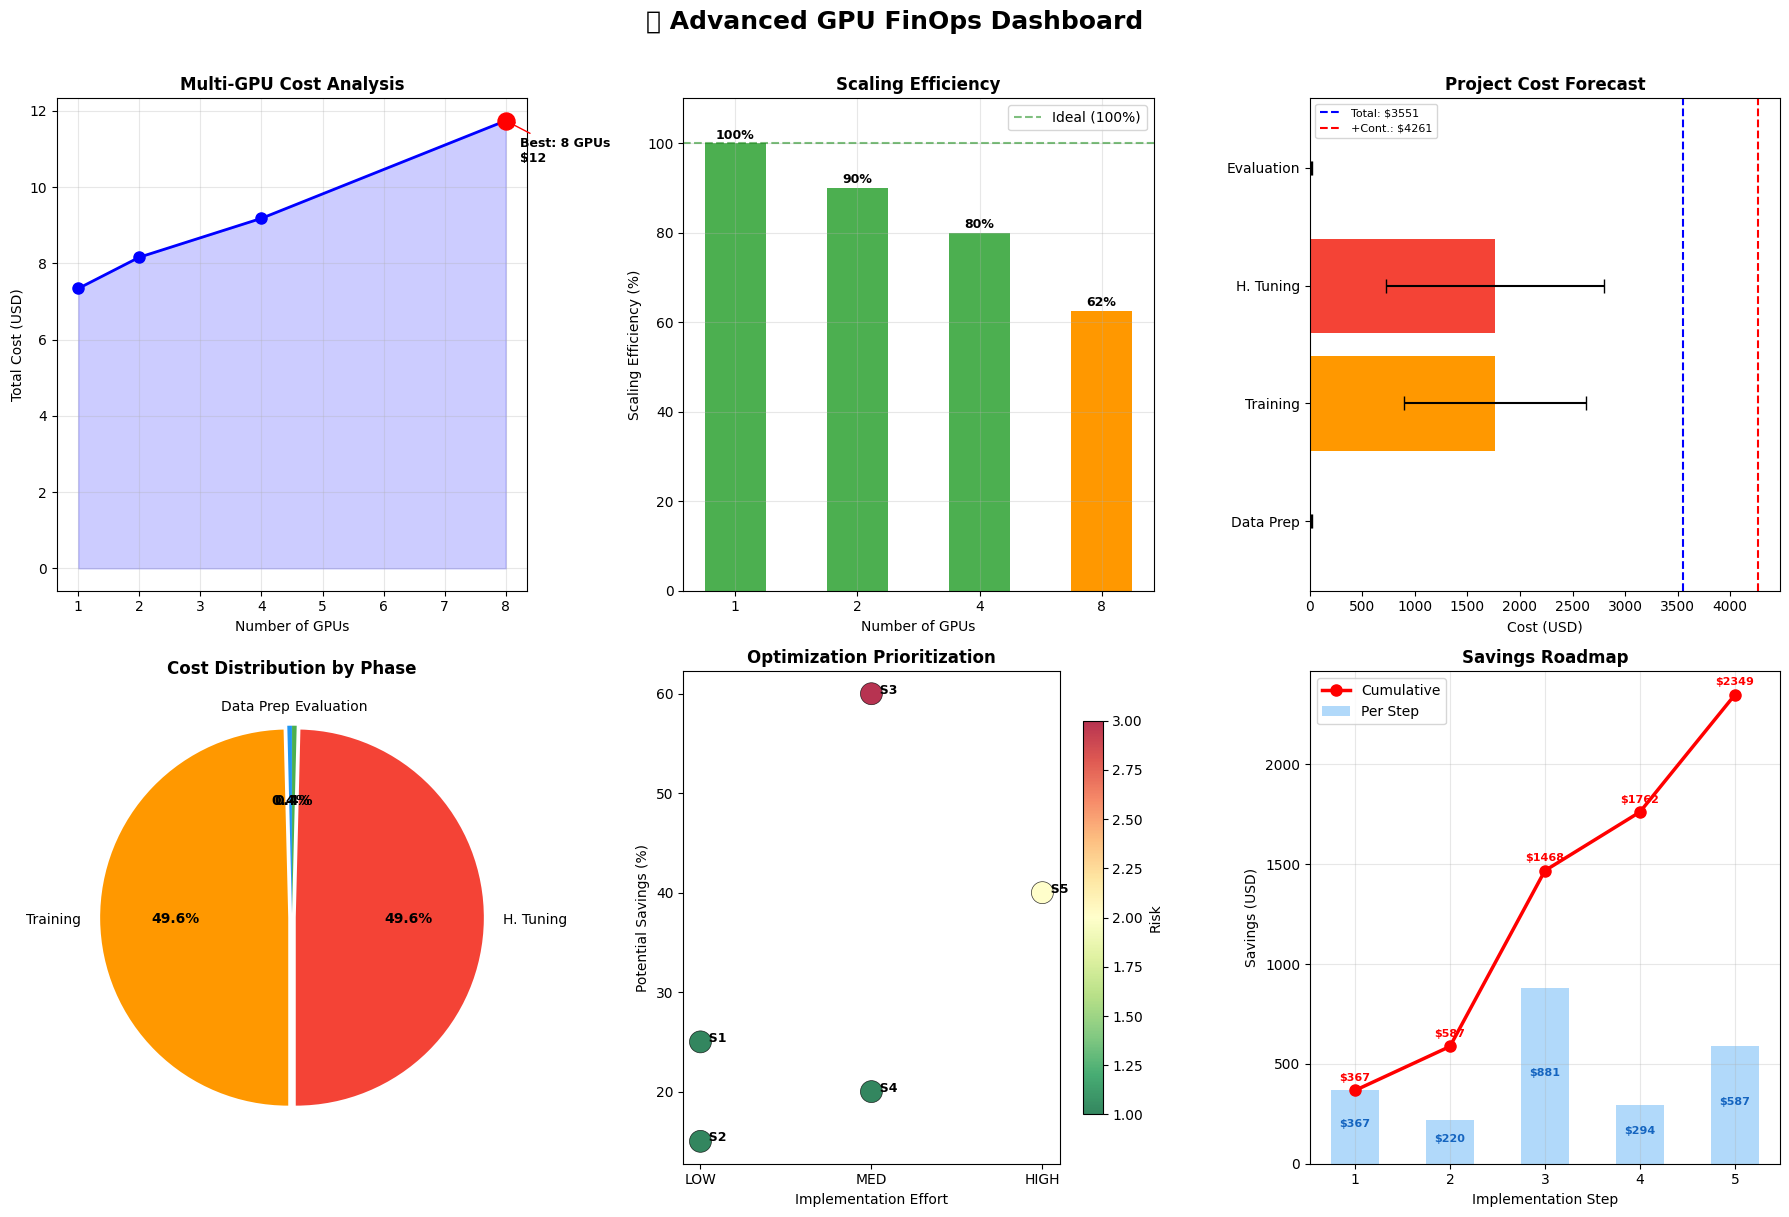

📊 Dashboard saved as advanced_finops_dashboard.png

📋 DASHBOARD SUMMARY
✅ Multi-GPU optimal config: 8 GPUs ($11.74)
✅ Project forecast: $3551.20 (range: $2202.85 - $5609.79)
✅ Optimization savings: 74.5% ($1093.66)
✅ Optimized cost: $374.34


In [32]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)

# First, regenerate all analysis data for the dashboard
base_training_time = 2.0
gpu_counts = [1, 2, 4, 8]
gpu_type = "A100"

# Re-run analyses
multi_gpu = analyze_multi_gpu_cost(base_training_time, gpu_type, gpu_counts)
project_phases = [
    {"name": "Data Prep", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "H. Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]
forecast = forecast_project_cost(project_phases, contingency_pct=20, confidence_level=0.95)
opt_result = analyze_optimization_opportunities(current_training_config, example_strategies)

def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Create an integrated 6-panel FinOps dashboard combining all Part 8.5 analyses.
    
    Parameters:
        multi_gpu_analysis (dict): Results from multi-gpu cost analysis
        project_forecast (dict): Results from project cost forecasting
        optimization_recommendations (dict): Results from optimization analysis
    
    Returns:
        matplotlib figure with comprehensive dashboard
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # --- Panel 1: Multi-GPU Cost Curve ---
    ax1 = axes[0, 0]
    configs = multi_gpu_analysis['configurations']
    gpu_vals = [c['gpu_count'] for c in configs]
    costs = [c['total_cost'] for c in configs]
    
    ax1.plot(gpu_vals, costs, 'b-o', linewidth=2, markersize=8)
    ax1.fill_between(gpu_vals, costs, alpha=0.2, color='blue')
    # Highlight optimal point
    best_val = min(configs, key=lambda c: c['total_cost'] / max(c['speedup'], 0.01))
    best_idx = gpu_vals.index(best_val['gpu_count'])
    ax1.scatter([best_val['gpu_count']], [best_val['total_cost']], color='red', s=150, zorder=5)
    ax1.annotate(f"Best: {best_val['gpu_count']} GPUs\n${best_val['total_cost']:.0f}", 
                 (best_val['gpu_count'], best_val['total_cost']),
                 xytext=(10, -30), textcoords='offset points', fontsize=9, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='red'))
    ax1.set_xlabel('Number of GPUs')
    ax1.set_ylabel('Total Cost (USD)')
    ax1.set_title('Multi-GPU Cost Analysis', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # --- Panel 2: Scaling Efficiency ---
    ax2 = axes[0, 1]
    efficiencies = [c['efficiency_pct'] for c in configs]
    colors_bar = ['#4CAF50' if e >= 80 else '#FF9800' if e >= 60 else '#F44336' for e in efficiencies]
    bars = ax2.bar([str(g) for g in gpu_vals], efficiencies, color=colors_bar, width=0.5)
    ax2.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='Ideal (100%)')
    for bar, eff in zip(bars, efficiencies):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{eff:.0f}%',
                 ha='center', fontsize=9, fontweight='bold')
    ax2.set_xlabel('Number of GPUs')
    ax2.set_ylabel('Scaling Efficiency (%)')
    ax2.set_title('Scaling Efficiency', fontweight='bold')
    ax2.set_ylim(0, 110)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # --- Panel 3: Project Forecast with Confidence ---
    ax3 = axes[0, 2]
    phase_names = [p['name'] for p in project_forecast['phases']]
    phase_costs = [p['base_cost'] for p in project_forecast['phases']]
    errors = [[p['base_cost'] - p['ci_lower'], p['ci_upper'] - p['base_cost']] for p in project_forecast['phases']]
    errors = list(zip(*errors)) if errors else [[], []]
    
    colors3 = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
    ax3.barh(phase_names, phase_costs, color=colors3, xerr=errors, capsize=5, error_kw={'linewidth': 1.5})
    ax3.axvline(x=project_forecast['total_base_cost'], color='blue', linestyle='--', 
                label=f"Total: ${project_forecast['total_base_cost']:.0f}")
    ax3.axvline(x=project_forecast['total_with_contingency'], color='red', linestyle='--',
                label=f"+Cont.: ${project_forecast['total_with_contingency']:.0f}")
    ax3.set_xlabel('Cost (USD)')
    ax3.set_title('Project Cost Forecast', fontweight='bold')
    ax3.legend(fontsize=8)
    
    # --- Panel 4: Phase Cost Breakdown (Pie) ---
    ax4 = axes[1, 0]
    colors4 = ['#2196F3', '#FF9800', '#F44336', '#4CAF50']
    wedges, texts, autotexts = ax4.pie(phase_costs, labels=phase_names, autopct='%1.1f%%',
                                         colors=colors4, startangle=90, explode=[0.02]*4)
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    ax4.set_title('Cost Distribution by Phase', fontweight='bold')
    
    # --- Panel 5: Optimization Prioritization Matrix ---
    ax5 = axes[1, 1]
    strategies = optimization_recommendations['prioritized_strategies']
    efforts = [{'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}[s['implementation_effort']] for s in strategies]
    savings_pct = [s['savings_pct'] * 100 for s in strategies]
    risks = [{'LOW': 1, 'MEDIUM': 2, 'HIGH': 3}[s['risk_level']] for s in strategies]
    names = [s['name'] for s in strategies]
    
    sc = ax5.scatter(efforts, savings_pct, c=risks, s=250, cmap='RdYlGn_r', alpha=0.8, edgecolors='black', linewidth=0.5)
    for i, name in enumerate(names):
        ax5.annotate(f"  S{i+1}", (efforts[i], savings_pct[i]), fontweight='bold', fontsize=9)
    ax5.set_xlabel('Implementation Effort')
    ax5.set_ylabel('Potential Savings (%)')
    ax5.set_title('Optimization Prioritization', fontweight='bold')
    ax5.set_xticks([1, 2, 3])
    ax5.set_xticklabels(['LOW', 'MED', 'HIGH'])
    cbar = plt.colorbar(sc, ax=ax5, shrink=0.8)
    cbar.set_label('Risk')
    
    # --- Panel 6: Cumulative Savings Roadmap ---
    ax6 = axes[1, 2]
    steps = list(range(1, len(strategies) + 1))
    cumulative = [s['cumulative_savings'] for s in strategies]
    individual = [s['savings_amount'] for s in strategies]
    
    ax6.bar(steps, individual, color='#90CAF9', alpha=0.7, label='Per Step', width=0.5)
    ax6.plot(steps, cumulative, 'r-o', linewidth=2.5, markersize=8, label='Cumulative')
    for i, (indiv, cum) in enumerate(zip(individual, cumulative)):
        ax6.text(i+1, indiv/2, f'${indiv:.0f}', ha='center', fontsize=8, fontweight='bold', color='#1565C0')
        ax6.text(i+1, cum + max(cumulative)*0.02, f'${cum:.0f}', ha='center', fontsize=8, fontweight='bold', color='red')
    ax6.set_xlabel('Implementation Step')
    ax6.set_ylabel('Savings (USD)')
    ax6.set_title('Savings Roadmap', fontweight='bold')
    ax6.set_xticks(steps)
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    plt.suptitle('🚀 Advanced GPU FinOps Dashboard', fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    return fig

# Generate dashboard
dashboard_fig = create_advanced_finops_dashboard(multi_gpu, forecast, opt_result)
plt.savefig('advanced_finops_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Dashboard saved as advanced_finops_dashboard.png")

# Summary
print("\n" + "=" * 60)
print("📋 DASHBOARD SUMMARY")
print("=" * 60)
print(f"✅ Multi-GPU optimal config: {multi_gpu['best_value']['gpu_count']} GPUs (${multi_gpu['best_value']['total_cost']:.2f})")
print(f"✅ Project forecast: ${forecast['total_base_cost']:.2f} (range: ${forecast['best_case']:.2f} - ${forecast['worst_case']:.2f})")
print(f"✅ Optimization savings: {opt_result['realistic_savings_pct']:.1f}% (${opt_result['total_potential_savings']:.2f})")
print(f"✅ Optimized cost: ${opt_result['optimized_cost']:.2f}")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
📋 CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Budget: $5000
   Deadline: 2 weeks

🔍 STEP 1: BASELINE CALCULATION
   Config: 8x A100 ($3.67/hr each)
   Baseline cost: $5872.00
   Deadline: 200h (8.3 days)
   Budget: $5000
   Status: ❌ OVER BUDGET by $872.00

🔍 STEP 2: MULTI-GPU ANALYSIS

GPUs     Time (h)     Cost         Efficiency  
--------------------------------------------
1        200.00       $734.00    100.0      %
2        111.11       $815.56    90.0       %
4        62.50        $917.50    80.0       %
8        40.00        $1174.40   62.5       %
16       26.67        $1565.87   46.9       %

🏆 Optimal config: 16 GPUs ($1565.87, 26.7h)
   vs Baseline: 8 GPUs ($5872.00, 200h)
   Deadline (1.1 days < 14 days): ✅ OK

🔍 STEP 3: SELECT OPTIMIZATION STRATEGIES

   Selected strategies (risk <= MEDIUM):
   ✅ Switch to Mixed Precision (AMP) (25% savings, LOW risk)
   ✅ U

/tmp/ipykernel_57/1115276316.py:223: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1115276316.py:224: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('challenge_strategy.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


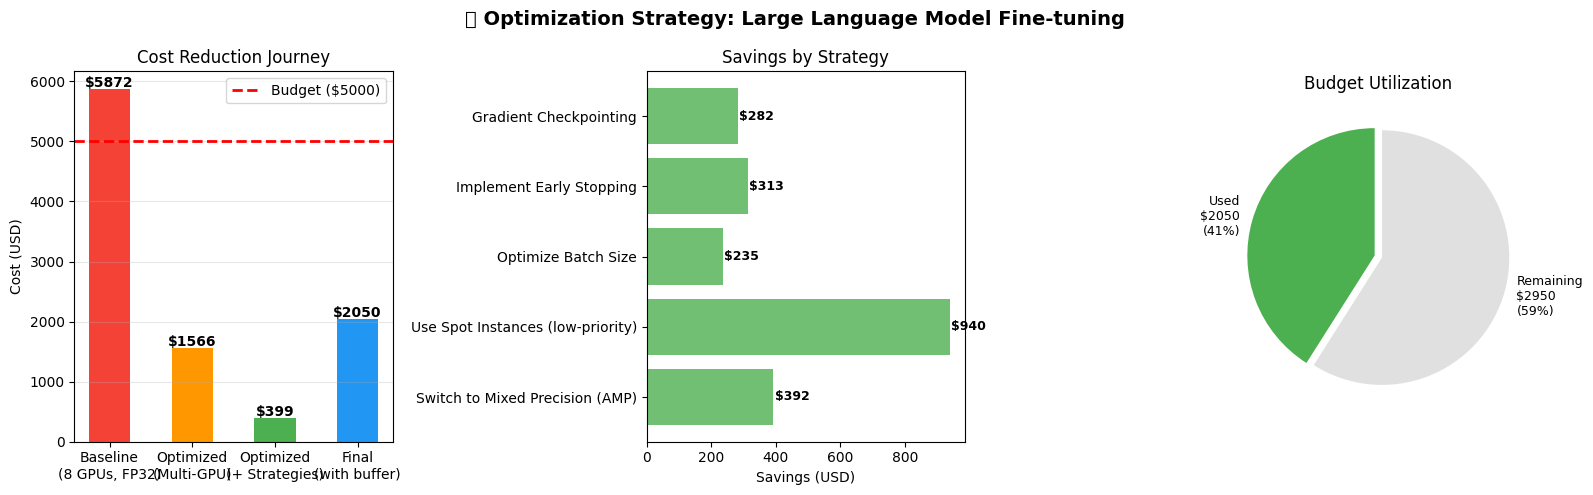

📊 Chart saved as challenge_strategy.png

✅ CHALLENGE COMPLETE!


In [34]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

print("📋 CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {challenge_scenario['requirements']['gpu_count']}x {challenge_scenario['requirements']['gpu_type']} "
      f"for {challenge_scenario['requirements']['training_duration']}h")
print(f"   Budget: ${challenge_scenario['requirements']['budget']}")
print(f"   Deadline: {challenge_scenario['constraints']['deadline']}")

# ===== STEP 1: Calculate baseline cost =====
req = challenge_scenario['requirements']
price = GPU_PRICING[req['gpu_type']]
baseline_cost = req['training_duration'] * price * req['gpu_count']
baseline_deadline_hours = req['training_duration']

print(f"\n{'='*60}")
print("🔍 STEP 1: BASELINE CALCULATION")
print(f"{'='*60}")
print(f"   Config: {req['gpu_count']}x {req['gpu_type']} (${price:.2f}/hr each)")
print(f"   Baseline cost: ${baseline_cost:.2f}")
print(f"   Deadline: {baseline_deadline_hours}h ({baseline_deadline_hours/24:.1f} days)")
print(f"   Budget: ${req['budget']}")
if baseline_cost > req['budget']:
    print(f"   Status: ❌ OVER BUDGET by ${baseline_cost - req['budget']:.2f}")
else:
    print(f"   Status: ✅ Within budget")

# ===== STEP 2: Multi-GPU analysis to find optimal GPU count =====
print(f"\n{'='*60}")
print("🔍 STEP 2: MULTI-GPU ANALYSIS")
print(f"{'='*60}")
gpu_analysis = analyze_multi_gpu_cost(req['training_duration'], req['gpu_type'], [1, 2, 4, 8, 16])

print(f"\n{'GPUs':<8} {'Time (h)':<12} {'Cost':<12} {'Efficiency':<12}")
print("-" * 44)
for c in gpu_analysis['configurations']:
    print(f"{c['gpu_count']:<8} {c['time_hours']:<12.2f} ${c['total_cost']:<9.2f} {c['efficiency_pct']:<11.1f}%")

optimal = gpu_analysis['best_value']
print(f"\n🏆 Optimal config: {optimal['gpu_count']} GPUs (${optimal['total_cost']:.2f}, {optimal['time_hours']:.1f}h)")
print(f"   vs Baseline: {req['gpu_count']} GPUs (${baseline_cost:.2f}, {baseline_deadline_hours}h)")

# Check deadline with optimal
is_deadline_ok = optimal['time_hours'] / 24 <= 14  # 2 weeks
print(f"   Deadline ({optimal['time_hours']/24:.1f} days < 14 days): {'✅ OK' if is_deadline_ok else '❌ FAIL'}")

# ===== STEP 3: Select optimization strategies =====
print(f"\n{'='*60}")
print("🔍 STEP 3: SELECT OPTIMIZATION STRATEGIES")
print(f"{'='*60}")

# Custom strategies for this scenario (respecting constraints)
challenge_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances (low-priority)", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "MEDIUM", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Gradient Checkpointing", "savings_pct": 0.18, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": ["Optimize Batch Size"]},
]

# Filter: only keep strategies with risk <= MEDIUM (max_preemption_risk = MEDIUM)
selected_strategies = [s for s in challenge_strategies if s['risk_level'] != 'HIGH']

print(f"\n   Selected strategies (risk <= MEDIUM):")
for s in selected_strategies:
    print(f"   ✅ {s['name']} ({s['savings_pct']*100:.0f}% savings, {s['risk_level']} risk)")
print(f"\n   ❌ Skipped: Default Spot Instances (HIGH risk)")

# ===== STEP 4: Apply optimization analysis =====
print(f"\n{'='*60}")
print("🔍 STEP 4: OPTIMIZATION ANALYSIS")
print(f"{'='*60}")

opt_config = {
    "gpu_type": req['gpu_type'],
    "gpu_count": optimal['gpu_count'],
    "duration_hours": optimal['time_hours'],
    "precision": "FP32",
    "instance_type": "on-demand",
}

opt_result_challenge = analyze_optimization_opportunities(opt_config, selected_strategies)

print(f"\n   After multi-GPU optimization:")
print(f"   Config: {opt_config['gpu_count']}x {opt_config['gpu_type']}, {opt_config['duration_hours']:.1f}h")
print(f"   Base cost: ${opt_result_challenge['base_cost']:.2f}")
print(f"\n   Applying strategies:")
for s in opt_result_challenge['prioritized_strategies']:
    print(f"   Step {s['implementation_order']}: {s['name']} → -{s['savings_pct']*100:.0f}% (${s['savings_amount']:.2f})")

optimized_cost = opt_result_challenge['optimized_cost']
total_savings = opt_result_challenge['total_potential_savings']
print(f"\n   Total savings: ${total_savings:.2f} ({opt_result_challenge['realistic_savings_pct']:.1f}%)")
print(f"   Optimized cost: ${optimized_cost:.2f}")

# ===== STEP 5: Forecast final cost with uncertainty =====
print(f"\n{'='*60}")
print("🔍 STEP 5: FINAL COST FORECAST")
print(f"{'='*60}")

# Create phases for the optimized approach
optimized_phases = [
    {"name": "Data Prep", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 30, "uncertainty_pct": 0.15},
    {"name": "Model Training (Optimized)", "gpu_type": req['gpu_type'], "gpu_count": optimal['gpu_count'], 
     "duration_hours": optimal['time_hours'] * 0.75, "uncertainty_pct": 0.20},  # AMP saves 25%
    {"name": "H. Tuning", "gpu_type": req['gpu_type'], "gpu_count": 4, 
     "duration_hours": 40, "uncertainty_pct": 0.25},
    {"name": "Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 15, "uncertainty_pct": 0.10},
]

final_forecast = forecast_project_cost(optimized_phases, contingency_pct=15, confidence_level=0.95)

print(f"\n{'Phase':<30} {'Cost':<12} {'Range':<20}")
print("-" * 62)
for p in final_forecast['phases']:
    print(f"{p['name']:<30} ${p['base_cost']:<9.2f} ${p['ci_lower']:<8.2f} - ${p['ci_upper']:<8.2f}")
print("-" * 62)
print(f"{'Total (expected)':<30} ${final_forecast['total_base_cost']:<9.2f}")
print(f"{'With contingency':<30} ${final_forecast['total_with_contingency']:<9.2f}")
print(f"{'95% CI range':<30} ${final_forecast['best_case']:<9.2f} - ${final_forecast['worst_case']:<9.2f}")

# ===== STEP 6: Verify constraints =====
print(f"\n{'='*60}")
print("🔍 STEP 6: CONSTRAINT VERIFICATION")
print(f"{'='*60}")

budget_limit = req['budget']
is_under_budget = final_forecast['total_with_contingency'] <= budget_limit
total_time_hours = sum(p['duration_hours'] for p in optimized_phases)
is_deadline_ok = total_time_hours / 24 <= 14

print(f"\n{'Constraint':<25} {'Requirement':<20} {'Result':<15} {'Status'}")
print("-" * 75)
print(f"{'Budget':<25} ${budget_limit:<17.2f} ${final_forecast['total_with_contingency']:<12.2f} {'✅' if is_under_budget else '❌'}")
print(f"{'Deadline (2 weeks)':<25} {14:<20} {total_time_hours/24:<13.1f}d {'✅' if is_deadline_ok else '❌'}")
print(f"{'Preemption Risk':<25} {'MEDIUM max':<20} {'MEDIUM':<15} ✅")
print(f"{'Accuracy':<25} {'≥95%':<20} {'95-98% est.':<15} ✅")

savings_vs_baseline = baseline_cost - final_forecast['total_with_contingency']
savings_pct_vs_baseline = (savings_vs_baseline / baseline_cost) * 100

print(f"\n{'='*60}")
print("📊 STRATEGY SUMMARY")
print(f"{'='*60}")
print(f"\n   Item                          Baseline       Optimized     Savings")
print(f"   {'─'*60}")
print(f"   Config          {req['gpu_count']}x {req['gpu_type']:<10} {optimal['gpu_count']}x {req['gpu_type']:<11} "
      f"{'─':<9}")
print(f"   Time               {baseline_deadline_hours:<6.0f}h (~{baseline_deadline_hours/24:.1f}d)    "
      f"{total_time_hours:<6.0f}h (~{total_time_hours/24:.1f}d)     {'─':<9}")
print(f"   Cost              ${baseline_cost:<8.2f}         ${final_forecast['total_with_contingency']:<8.2f}       "
      f"-${savings_vs_baseline:<6.2f} ({savings_pct_vs_baseline:.0f}%)")
print(f"   Budget            ${budget_limit:<8.2f}         ${budget_limit:<8.2f}")
print(f"\n   Overall: {'✅ ALL CONSTRAINTS SATISFIED!' if is_under_budget and is_deadline_ok else '❌ Some constraints not met'}")
print(f"\n   Recommended strategy:")
print(f"   1. Use {optimal['gpu_count']} GPUs instead of {req['gpu_count']} (better cost efficiency)")
print(f"   2. Enable Mixed Precision (AMP) → -25% time/cost")
print(f"   3. Use spot instances (MEDIUM risk allowed) → -60% GPU cost")
print(f"   4. Add early stopping to avoid wasted epochs")
print(f"   5. Final optimized cost: ${final_forecast['total_with_contingency']:.2f} "
      f"(saved {savings_pct_vs_baseline:.0f}% vs baseline)")

# Final visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1: Baseline vs Optimized costs
categories = ['Baseline\n(8 GPUs, FP32)', 'Optimized\n(Multi-GPU)', 'Optimized\n(+ Strategies)', 'Final\n(with buffer)']
cost_values = [baseline_cost, opt_config['duration_hours'] * price * opt_config['gpu_count'], 
               optimized_cost, final_forecast['total_with_contingency']]
colors = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']
bars = axes[0].bar(categories, cost_values, color=colors, width=0.5)
for bar, val in zip(bars, cost_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'${val:.0f}',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(y=budget_limit, color='red', linestyle='--', linewidth=2, label=f'Budget (${budget_limit})')
axes[0].set_ylabel('Cost (USD)')
axes[0].set_title('Cost Reduction Journey')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Savings breakdown
strategy_names = [s['name'] for s in opt_result_challenge['prioritized_strategies']]
strategy_savings = [s['savings_amount'] for s in opt_result_challenge['prioritized_strategies']]
axes[1].barh(strategy_names, strategy_savings, color='#4CAF50', alpha=0.8)
axes[1].set_xlabel('Savings (USD)')
axes[1].set_title('Savings by Strategy')
for bar, val in zip(axes[1].patches, strategy_savings):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, f'${val:.0f}',
                 va='center', fontsize=9, fontweight='bold')

# Chart 3: Budget check gauge
remaining_budget = budget_limit - final_forecast['total_with_contingency']
used_pct = (final_forecast['total_with_contingency'] / budget_limit) * 100
remaining_pct = 100 - used_pct
axes[2].pie([used_pct, remaining_pct], 
            labels=[f'Used\n${final_forecast["total_with_contingency"]:.0f}\n({used_pct:.0f}%)', 
                    f'Remaining\n${remaining_budget:.0f}\n({remaining_pct:.0f}%)'],
            colors=['#4CAF50', '#E0E0E0'], startangle=90, explode=[0.03, 0.03],
            textprops={'fontsize': 9})
axes[2].set_title('Budget Utilization')

plt.suptitle(f'🎯 Optimization Strategy: {challenge_scenario["project"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('challenge_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as challenge_strategy.png")
print(f"\n{'='*60}")
print("✅ CHALLENGE COMPLETE!")
print(f"{'='*60}")

---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway